In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Superstore.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/Superstore.csv'

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, analysis,
and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Customer_Segmentation_py.csv")

df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [5]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 113036
Number of columns: 18

Column names:
['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']

Data types:
Date                  str
Day                 int64
Month                 str
Year                int64
Customer_Age        int64
Age_Group             str
Customer_Gender       str
Country               str
State                 str
Product_Category      str
Sub_Category          str
Product               str
Order_Quantity      int64
Unit_Cost           int64
Unit_Price          int64
Profit              int64
Cost                int64
Revenue             int64
dtype: object

Missing values:
Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_

In [6]:
# Basic information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Date              113036 non-null  str  
 1   Day               113036 non-null  int64
 2   Month             113036 non-null  str  
 3   Year              113036 non-null  int64
 4   Customer_Age      113036 non-null  int64
 5   Age_Group         113036 non-null  str  
 6   Customer_Gender   113036 non-null  str  
 7   Country           113036 non-null  str  
 8   State             113036 non-null  str  
 9   Product_Category  113036 non-null  str  
 10  Sub_Category      113036 non-null  str  
 11  Product           113036 non-null  str  
 12  Order_Quantity    113036 non-null  int64
 13  Unit_Cost         113036 non-null  int64
 14  Unit_Price        113036 non-null  int64
 15  Profit            113036 non-null  int64
 16  Cost              113036 non-null  int64
 17  Revenue           113

In [7]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1000


In [11]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1000


In [8]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Check the result
print(df["Date"].dtype)
print(df["Date"].head())

datetime64[us]
0   2013-11-26
1   2015-11-26
2   2014-03-23
3   2016-03-23
4   2014-05-15
Name: Date, dtype: datetime64[us]


In [9]:
# Check numerical columns for negative values
numeric_columns = [
    "Customer_Age",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Profit",
    "Cost",
    "Revenue"
]

df[numeric_columns].describe()

,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


In [10]:
# Calculate expected values
df["Expected_Cost"] = df["Order_Quantity"] * df["Unit_Cost"]
df["Expected_Revenue"] = df["Order_Quantity"] * df["Unit_Price"]

# Check differences
df["Cost_Difference"] = df["Cost"] - df["Expected_Cost"]
df["Revenue_Difference"] = df["Revenue"] - df["Expected_Revenue"]

print("Cost mismatches:", (df["Cost_Difference"] != 0).sum())
print("Revenue mismatches:", (df["Revenue_Difference"] != 0).sum())

Cost mismatches: 0
Revenue mismatches: 106467


In [12]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Remove temporary validation columns
df = df.drop(
    columns=["Expected_Cost", "Expected_Revenue",
             "Cost_Difference", "Revenue_Difference"],
    errors="ignore"
)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Dataset shape after cleaning:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Dataset shape after cleaning: (112036, 18)
Duplicate rows remaining: 0


In [13]:
# Create useful time-based features
df["Month_Number"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

# Profit margin
df["Profit_Margin"] = (df["Profit"] / df["Revenue"]) * 100

# Average selling price per order
df["Average_Order_Value"] = df["Revenue"] / df["Order_Quantity"]

# Display the new columns
df[
    [
        "Date",
        "Year",
        "Month",
        "Month_Number",
        "Quarter",
        "Year_Month",
        "Revenue",
        "Profit",
        "Profit_Margin",
        "Average_Order_Value"
    ]
].head()

,Date,Year,Month,Month_Number,Quarter,Year_Month,Revenue,Profit,Profit_Margin,Average_Order_Value
0,2013-11-26,2013,November,11,4,2013-11,950,590,62.105263,118.750000
1,2015-11-26,2015,November,11,4,2015-11,950,590,62.105263,118.750000
2,2014-03-23,2014,March,3,1,2014-03,2401,1366,56.892961,104.391304
3,2016-03-23,2016,March,3,1,2016-03,2088,1188,56.896552,104.400000
4,2014-05-15,2014,May,5,2,2014-05,418,238,56.937799,104.500000


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nData types:")
print(df.dtypes)

Rows: 112036
Columns: 23

Missing values:
0

Data types:
Date                   datetime64[us]
Day                             int64
Month                             str
Year                            int64
Customer_Age                    int64
Age_Group                         str
Customer_Gender                   str
Country                           str
State                             str
Product_Category                  str
Sub_Category                      str
Product                           str
Order_Quantity                  int64
Unit_Cost                       int64
Unit_Price                      int64
Profit                          int64
Cost                            int64
Revenue                         int64
Month_Number                    int32
Quarter                         int32
Year_Month                        str
Profit_Margin                 float64
Average_Order_Value           float64
dtype: object


## 2. Load Dataset

The cleaned retail sales dataset is loaded from the project's `data` folder.

In [15]:
df.to_csv("../data/cleaned_retail_sales.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Total Revenue:", df["Revenue"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Orders:", len(df))
print("Total Quantity Sold:", df["Order_Quantity"].sum())

Total Revenue: 84826772
Total Profit: 32046239
Total Orders: 112036
Total Quantity Sold: 1333705


In [17]:
df[["Revenue", "Profit", "Order_Quantity", "Profit_Margin", "Average_Order_Value"]].describe()

,Revenue,Profit,Order_Quantity,Profit_Margin,Average_Order_Value
count,112036.000000,112036.000000,112036.000000,112036.000000,112036.000000
mean,757.138527,286.035194,11.904254,47.212544,405.465831
std,1312.061623,454.852634,9.564877,16.385344,825.758446
min,2.000000,-30.000000,1.000000,-3.703704,1.500000
25%,64.000000,29.000000,2.000000,35.707845,4.888889
50%,226.000000,103.000000,10.000000,52.631579,23.000000
75%,806.000000,360.000000,20.000000,59.677419,63.333333
max,58074.000000,15096.000000,32.000000,75.000000,3578.000000


### 2. Profit Trend Over Time

This graph shows the change in profit over time.
It helps identify periods with strong or weak profitability.

In [ ]:
# Calculate expected values
df["Expected_Cost"] = df["Order_Quantity"] * df["Unit_Cost"]
df["Expected_Revenue"] = df["Order_Quantity"] * df["Unit_Price"]

# Check differences
df["Cost_Difference"] = df["Cost"] - df["Expected_Cost"]
df["Revenue_Difference"] = df["Revenue"] - df["Expected_Revenue"]

print("Cost mismatches:", (df["Cost_Difference"] != 0).sum())
print("Revenue mismatches:", (df["Revenue_Difference"] != 0).sum())

Cost mismatches: 0
Revenue mismatches: 106467


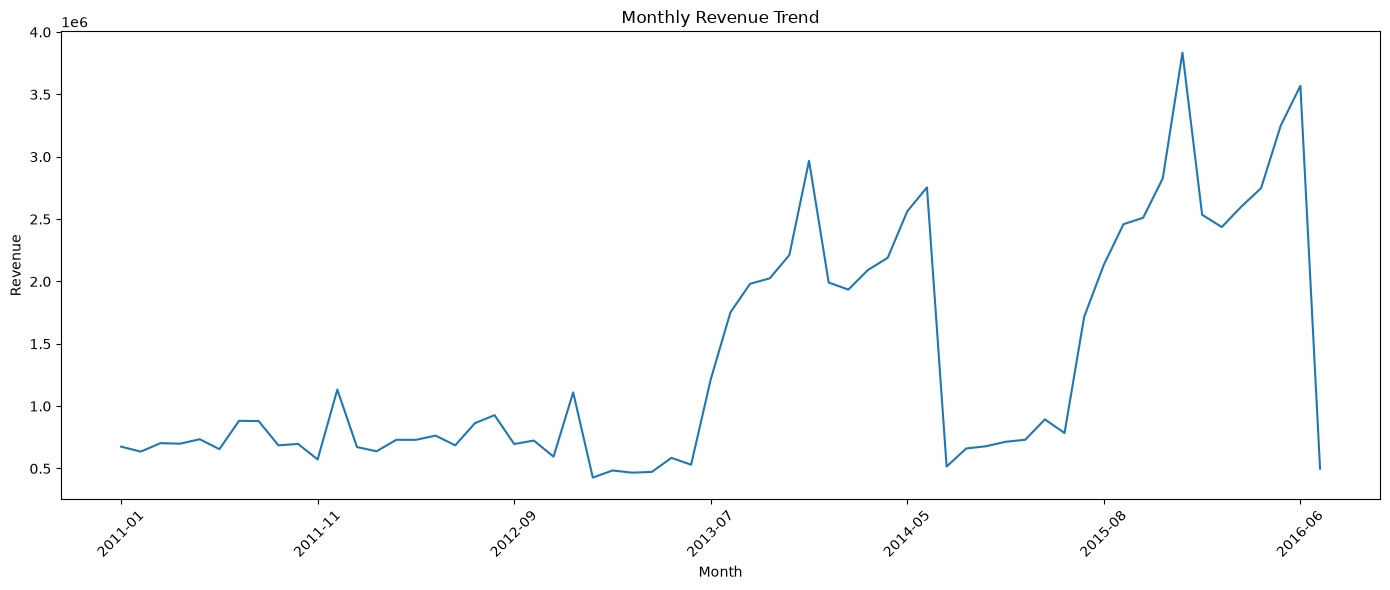

In [18]:
monthly_sales = df.groupby("Year_Month")["Revenue"].sum()

plt.figure(figsize=(14, 6))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. Revenue by Product Category

This visualization compares revenue across product categories.
It helps identify which categories generate the highest revenue.

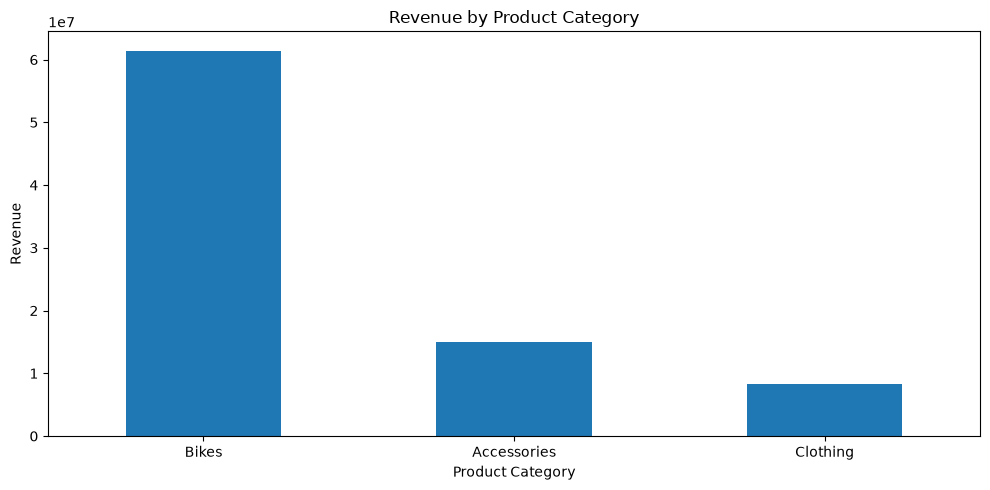

In [19]:
category_sales = df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Profit by Product Category

This visualization compares the profit generated by each product category. 
It helps identify the most profitable areas of the business.

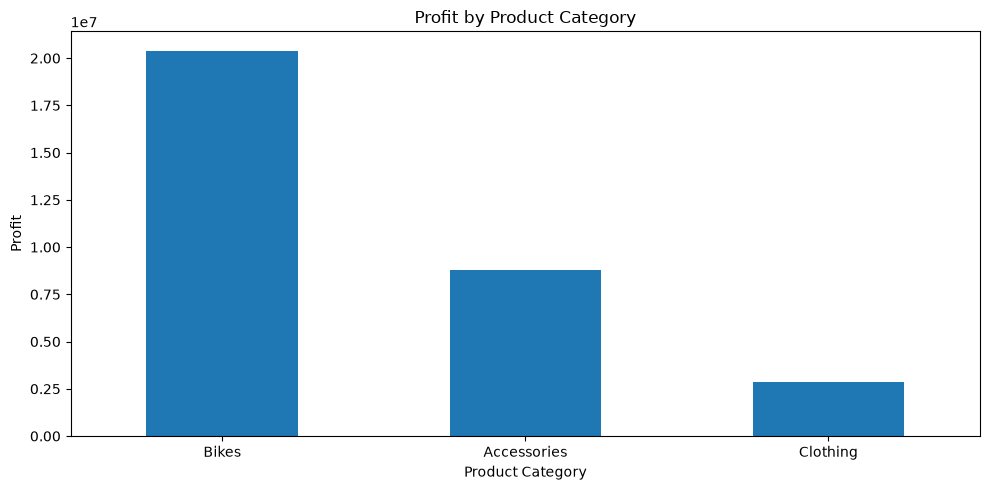

In [20]:
category_profit = df.groupby("Product_Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_profit.plot(kind="bar")
plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

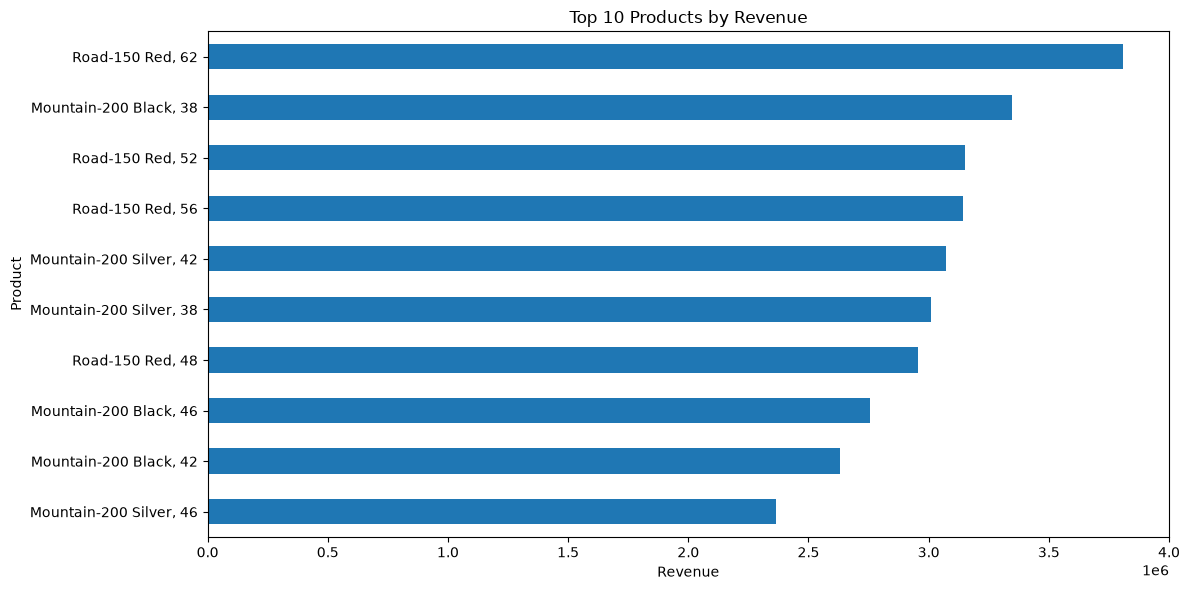

In [21]:
top_products = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [ ]:
## 5.5 Top 10 Products by Revenue

This analysis identifies the top 10 products based on total revenue.
It helps determine which products contribute the most to overall sales.

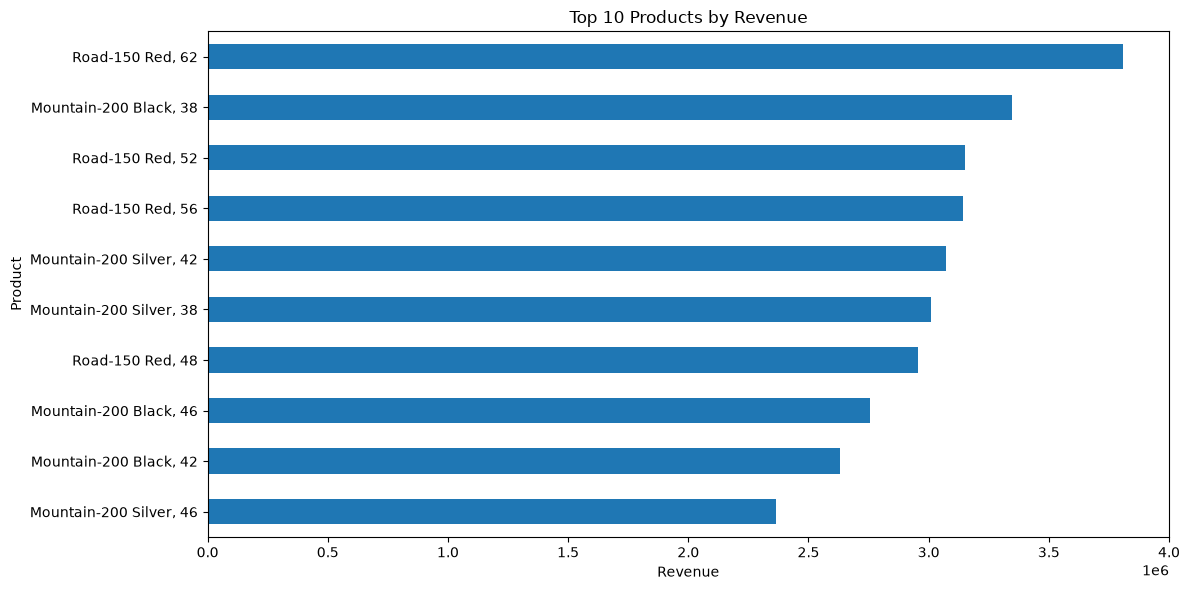

In [22]:
top_products = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 5.6 Revenue by Customer Age Group

This analysis examines revenue generated by different customer age groups.
It helps identify which age groups contribute the most to overall sales.

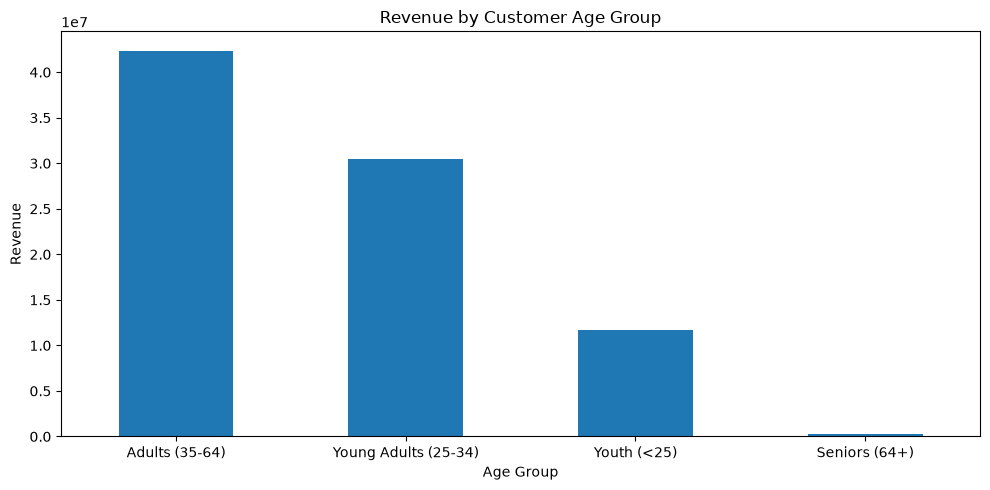

In [23]:
age_group_revenue = (
    df.groupby("Age_Group")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
age_group_revenue.plot(kind="bar")

plt.title("Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5.7 Revenue by Customer Gender

This analysis compares revenue generated by male and female customers.
It helps understand the contribution of each gender to overall sales.

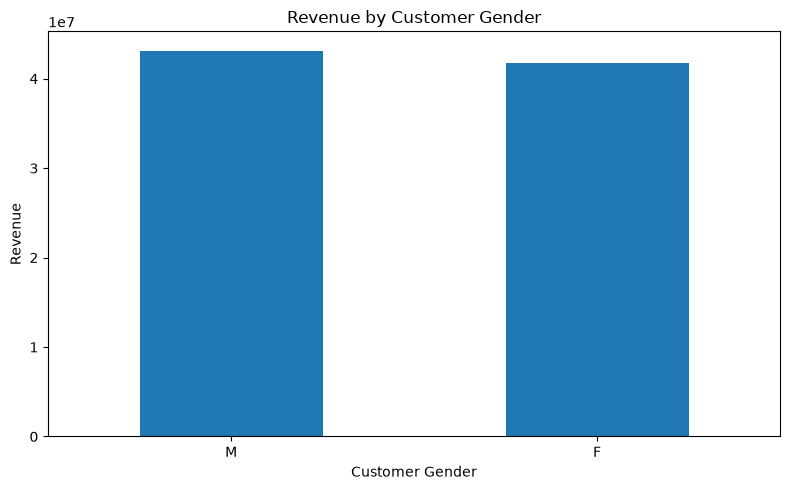

In [24]:
gender_revenue = (
    df.groupby("Customer_Gender")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
gender_revenue.plot(kind="bar")

plt.title("Revenue by Customer Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5.8 Revenue by Country

This analysis compares the total revenue generated across different countries.
It helps identify the strongest geographical markets for the business.

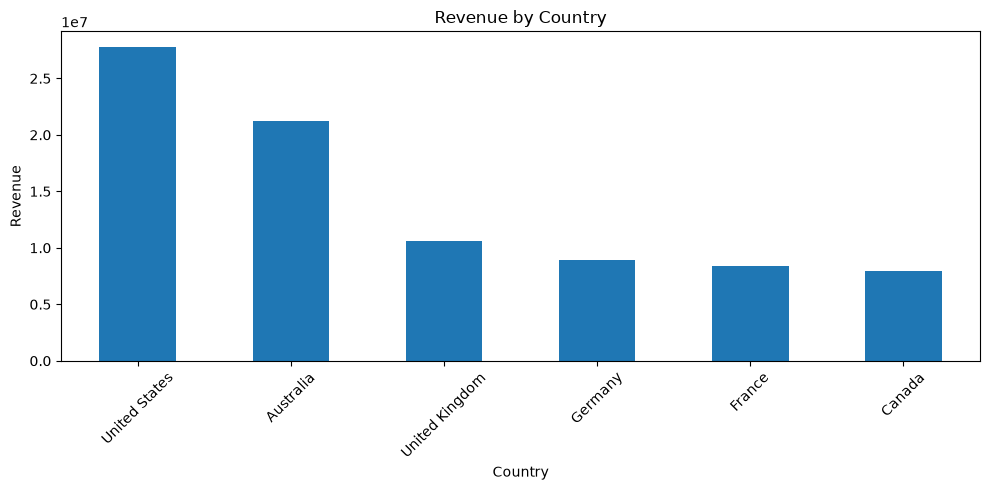

In [25]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
country_revenue.plot(kind="bar")

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.9 Revenue by Sub-Category

This analysis compares revenue across different product sub-categories.
It helps identify which types of products contribute the most to sales.

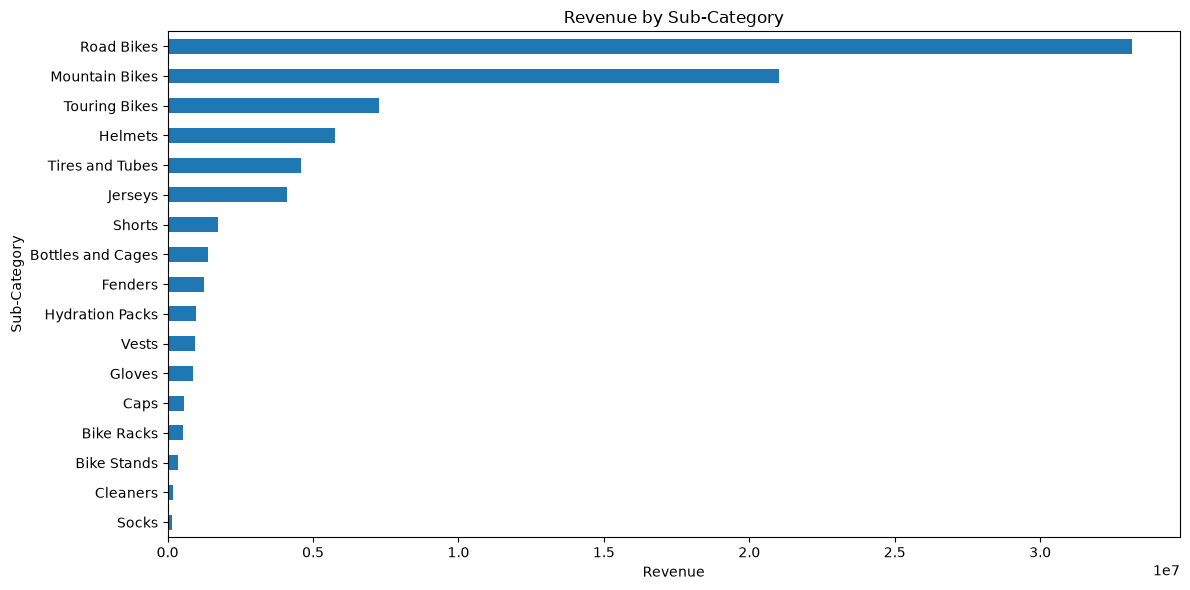

In [26]:
subcategory_revenue = (
    df.groupby("Sub_Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
subcategory_revenue.sort_values().plot(kind="barh")

plt.title("Revenue by Sub-Category")
plt.xlabel("Revenue")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

The cleaned dataset contains 112,036 records and 23 columns. 
The data was analyzed to identify sales trends, profitability, customer behavior, 
and product performance.

The following visualizations help understand the key patterns in the retail sales data.

## Key Insights

- The dataset contains 112,036 records after removing duplicate rows.
- Revenue and profit vary across different periods and product categories.
- Some product categories contribute significantly more revenue than others.
- Customer age groups show different purchasing patterns.
- Geographic and demographic factors influence sales performance.
- Product-level analysis helps identify high-performing products.

In [ ]:
## Conclusion

The exploratory data analysis provides useful insights into retail sales,
profitability, customer behavior, and product performance. These insights
can help businesses identify high-performing products and customer segments,
understand sales trends, and make better data-driven decisions.

In [ ]:
# Calculate expected values
df["Expected_Cost"] = df["Order_Quantity"] * df["Unit_Cost"]
df["Expected_Revenue"] = df["Order_Quantity"] * df["Unit_Price"]

# Check differences
df["Cost_Difference"] = df["Cost"] - df["Expected_Cost"]
df["Revenue_Difference"] = df["Revenue"] - df["Expected_Revenue"]

print("Cost mismatches:", (df["Cost_Difference"] != 0).sum())
print("Revenue mismatches:", (df["Revenue_Difference"] != 0).sum())

Cost mismatches: 0
Revenue mismatches: 106467


## Key Insights

Based on the exploratory data analysis, the following key insights were identified:

- Revenue and profit show variations across different time periods.
- Product categories contribute differently to overall revenue and profitability.
- Customer age groups have different purchasing patterns.
- Customer gender provides useful insights into sales behavior.
- Country and state-level analysis shows differences in sales performance.
- Some products generate significantly higher revenue and profit than others.
- Order quantity varies across products and customer segments.

## Business Recommendations

Based on the analysis, the business can:

- Focus on high-performing product categories and products.
- Identify opportunities to improve low-performing categories.
- Target customer segments with stronger purchasing activity.
- Analyze geographic performance to improve regional sales strategies.
- Monitor products with low profitability and review their pricing or costs.
- Use historical sales trends to support future sales and inventory planning.

## Conclusion

This project analyzed a retail sales dataset containing 113,036 records
and 18 original columns. The data was cleaned by removing duplicate records,
converting the Date column into a proper datetime format, and creating
additional features such as Year, Month Number, Quarter, Year-Month,
Profit Margin, and Average Order Value.

Exploratory Data Analysis was performed to understand sales trends,
profitability, customer behavior, product performance, and geographic
patterns. The analysis provides useful business insights that can support
better sales strategies, customer targeting, product management, and
data-driven decision-making.

Overall, the project demonstrates the complete data analytics workflow:
data collection, data cleaning, feature engineering, exploratory analysis,
visualization, insights generation, and business recommendations.

In [27]:
# Save cleaned dataset

cleaned_path = "../data/cleaned_retail_sales.csv"

df.to_csv(cleaned_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_path}")

Cleaned dataset saved to: ../data/cleaned_retail_sales.csv


In [28]:
plt.show()

In [29]:
plt.savefig("../outputs/graph1.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>